In [1]:
# @title Install dependencies
!pip install -q "transformers[torch]" trl datasets peft accelerate bitsandbytes pandasql python-Levenshtein

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.4/517.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.4 MB/s eta 0:00:00


In [ ]:
!pip install -U bitsandbytes
!pip install -U transformers accelerate peft

In [19]:
# @title Imports & global config

import gc
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer
import pandasql as ps
import Levenshtein as lev

# ----- Config générale -----
#MODEL_ID = "Qwen/Qwen2.5-Coder-7B"
MODEL_ID = "deepseek-ai/deepseek-coder-1.3b-base"
# Subset pour tester rapidement
TRAIN_NUM_SHARDS = 200
TRAIN_SHARD_INDEX = 0
TEST_NUM_SHARDS = 50
TEST_SHARD_INDEX = 0

MAX_EVAL_SAMPLES = 20  # nb d'exemples d'éval (augmente plus tard)
DO_TRAIN = True        # mets False si tu veux juste tester le pipeline sans relancer le training


In [26]:
dataset_name = "gretelai/synthetic_text_to_sql"
dataset = load_dataset(dataset_name)

print(dataset)

train_small = dataset["train"].shard(num_shards=TRAIN_NUM_SHARDS, index=TRAIN_SHARD_INDEX)
test_small  = dataset["test"].shard(num_shards=TEST_NUM_SHARDS,  index=TEST_SHARD_INDEX)

print("Train subset size:", len(train_small))
print("Test subset size:", len(test_small))

def format_prompt_train(example):
    return f"""### INSTRUCTION
Given the database schema below, write a SQL query that answers the following question.

### SCHEMA
{example['sql_context']}

### QUESTION
{example['sql_prompt']}

### QUERY
{example['sql']}
"""

def format_prompt_eval(example):
    return f"""### INSTRUCTION
You are an expert SQL query generator. Output ONLY a valid SQL query. Do not add explanations.

### SCHEMA
{example['sql_context']}

### QUESTION
{example['sql_prompt']}

### QUERY
""".strip()


def build_eval_prompt(row):
    return format_prompt_eval(row)


DatasetDict({
    train: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 5851
    })
})
Train subset size: 500
Test subset size: 118


In [27]:
# @title Normalization & evaluation helpers

def normalize_sql(sql: str) -> str:
    """Normalise une requête SQL pour comparaison :
    - lowercase
    - supprime retours à la ligne
    - compresse les espaces
    - enlève le ';' final
    """
    if sql is None:
        return ""
    s = sql.lower()
    s = s.replace("\n", " ").replace("\r", " ")
    s = " ".join(s.split())
    if s.endswith(";"):
        s = s[:-1].strip()
    return s


def levenshtein_ratio(a: str, b: str) -> float:
    """Ratio de similarité Levenshtein sur les chaînes normalisées."""
    a_n, b_n = normalize_sql(a), normalize_sql(b)
    if not a_n and not b_n:
        return 1.0
    return lev.ratio(a_n, b_n)


def build_tables_from_sql_context(sql_context: str) -> dict:
    """À partir du sql_context (CREATE + INSERT),
    crée des tables dans sqlite puis les récupère en DataFrames pandas.
    Retourne un dict {table_name: dataframe}.
    """
    conn = sqlite3.connect(":memory:")
    try:
        conn.executescript(sql_context)
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';")
        tables = [r[0] for r in cursor.fetchall()]

        tables_dict = {}
        for t in tables:
            df = pd.read_sql_query(f"SELECT * FROM {t};", conn)
            tables_dict[t] = df
        return tables_dict
    finally:
        conn.close()


def try_execute_with_pandasql(sql_context: str, query: str):
    """Construit des DataFrames à partir du sql_context, puis exécute la query avec pandasql.
    Retourne (success: bool, result_df: pd.DataFrame | None).
    """
    try:
        tables = build_tables_from_sql_context(sql_context)
        if not tables:
            return False, None
        local_env = tables.copy()
        res = ps.sqldf(query, local_env)
        return True, res
    except Exception:
        return False, None


def normalize_result_df(df: pd.DataFrame | None) -> pd.DataFrame | None:
    """Tri des colonnes et des lignes pour comparaison insensible à l'ordre."""
    if df is None:
        return None
    if df.empty:
        return df.reset_index(drop=True)
    df2 = df.copy()
    df2 = df2.reindex(sorted(df2.columns), axis=1)
    df2 = df2.sort_values(list(df2.columns)).reset_index(drop=True)
    return df2


# détecter présence d'INSERT INTO dans sql_context
def has_insert(sql_context: str) -> bool:
    if sql_context is None:
        return False
    return bool(re.search(r"\binsert\s+into\b", sql_context, flags=re.IGNORECASE))


def evaluate_example(example, generated_sql: str) -> dict:
    """Calcule les métriques pour un exemple :
    - exact match (sur SQL normalisé)
    - levenshtein ratio
    - gen_executable (pandasql)
    - exec_match (égalité des résultats SQL)

    exec_match n'est calculé QUE si sql_context contient INSERT INTO.
              Sinon exec_match = np.nan (et on track exec_match_eligible).
    """
    gold_sql = example["sql"]
    ctx = example["sql_context"]

    norm_gold = normalize_sql(gold_sql)
    norm_gen = normalize_sql(generated_sql)

    exact = int(norm_gold == norm_gen)
    lev_ratio_val = levenshtein_ratio(gold_sql, generated_sql)

    # Exécution via pandasql
    gold_ok, gold_df = try_execute_with_pandasql(ctx, gold_sql)
    gen_ok,  gen_df  = try_execute_with_pandasql(ctx, generated_sql)

    eligible = has_insert(ctx)

    exec_match = np.nan  #par défaut: non pris en compte
    if eligible and gold_ok and gen_ok and gold_df is not None and gen_df is not None:
        gold_norm_df = normalize_result_df(gold_df)
        gen_norm_df  = normalize_result_df(gen_df)
        exec_match = int(gold_norm_df.equals(gen_norm_df))

    return {
        "norm_exact": exact,
        "lev_ratio": lev_ratio_val,
        "gen_executable": int(gen_ok),
        "gold_executable": int(gold_ok),
        "exec_match": exec_match,                    # nan si non éligible
        "exec_match_eligible": int(eligible),        # pour coverage
    }


In [12]:
# @title Tokenizer & base model (4-bit, bf16)

from transformers import BitsAndBytesConfig

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.model_max_length = 512
tokenizer.truncation_side = "left"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    trust_remote_code=True,
)

base_model.config.use_cache = False
base_model.gradient_checkpointing_enable()
base_model.enable_input_require_grads()


In [13]:
# @title LoRA config & training args

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)

training_args = TrainingArguments(
    output_dir="./sql_finetune_results",
    per_device_train_batch_size=1,     #
    gradient_accumulation_steps=2,     #
    learning_rate=2e-4,
    num_train_epochs=1,                # 1 epoch = largement suffisant
    logging_steps=50,
    save_strategy="epoch",

    fp16=False,
    bf16=True,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    report_to="none",
)



In [29]:
# @title Fine-tuning with SFTTrainer (LoRA)

trainer = SFTTrainer(
    model=base_model,
    processing_class=tokenizer,
    train_dataset=train_small,
    formatting_func=format_prompt_train,
    peft_config=peft_config,
    args=training_args,
)


if DO_TRAIN:
    gc.collect()
    torch.cuda.empty_cache()
    print("=== Start training ===")
    trainer.train()
    adapter_save_path = "./sql_finetune_adapter"
    trainer.save_model(adapter_save_path)
    print("LoRA adapter saved to", adapter_save_path)
else:
    adapter_save_path = "./sql_finetune_adapter"
    print("Training skipped, expecting existing adapter at", adapter_save_path)


Applying formatting function to train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

In [30]:
# @title Reload base & finetuned models + pipelines

# Nettoyage mémoire
del trainer
gc.collect()
torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True,
)
ft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(ft_model, adapter_save_path)

pipe_base = pipeline(
    "text-generation",
    model=base_model,
    tokenizer=tokenizer,
    do_sample=False,
    max_new_tokens=256,
)

pipe_ft = pipeline(
    "text-generation",
    model=ft_model,
    tokenizer=tokenizer,
    do_sample=False,
    max_new_tokens=256,
)


Device set to use cuda:0
Device set to use cuda:0


In [38]:
# @title Eval function (base or finetuned)

def generate_sql_from_model(pipe, example) -> str:
    prompt = format_prompt_eval(example)
    out = pipe(prompt, max_new_tokens=256, do_sample=False)[0]["generated_text"]

    # 1) Récupérer ce qui vient après le prompt
    gen_sql = out[len(prompt):].strip()
    # 2) Nettoyages classiques
    gen_sql = gen_sql.replace("```sql", "").replace("```", "")
    gen_sql = gen_sql.split("###")[0]      # coupe tout trash type ### END
    gen_sql = gen_sql.split("```")[0]      # coupe bloc code
    gen_sql = gen_sql.split("\n")[0]       # garde un seul SELECT ...
    gen_sql = gen_sql.strip()

    # 3) Forcer un point-virgule
    if ";" not in gen_sql:
        gen_sql += ";"
    else:
        gen_sql = gen_sql.split(";")[0] + ";"

    return gen_sql


def eval_model(pipe, eval_dataset, max_samples: int = 30) -> pd.DataFrame:
    rows = []
    n = min(len(eval_dataset), max_samples)
    for i in tqdm(range(n)):
        ex = eval_dataset[i]
        gen_sql = generate_sql_from_model(pipe, ex)
        metrics = evaluate_example(ex, gen_sql)
        rows.append({
            "index": i,
            "prompt": ex["sql_prompt"],
            "gold_sql": ex["sql"],
            "generated_sql": gen_sql,
            **metrics,
        })
    return pd.DataFrame(rows)



In [39]:
results_base_df = eval_model(pipe_base, test_small, max_samples=MAX_EVAL_SAMPLES)
results_ft_df   = eval_model(pipe_ft,   test_small, max_samples=MAX_EVAL_SAMPLES)

print("Base eval df shape:", results_base_df.shape)
print("FT eval df shape:", results_ft_df.shape)

results_base_df.head(), results_ft_df.head()


100%|██████████| 20/20 [00:58<00:00,  2.92s/it]

Base eval df shape: (20, 10)
FT eval df shape: (20, 10)


(   index                                             prompt  \
 0      0  What is the average explainability score of cr...   
 1      1  Delete all records of rural infrastructure pro...   
 2      2  How many accidents have been recorded for Spac...   
 3      3  What is the maximum quantity of seafood sold i...   
 4      4  What is the total budget for movies released b...   
 
                                             gold_sql  \
 0  SELECT AVG(explainability_score) FROM creative...   
 1  DELETE FROM rural_infrastructure WHERE country...   
 2  SELECT launch_provider, COUNT(*) FROM Accident...   
 3                   SELECT MAX(quantity) FROM sales;   
 4  SELECT SUM(budget) FROM Movies_Release_Year WH...   
 
                                        generated_sql  norm_exact  lev_ratio  \
 0  SELECT AVG(explainability_score) FROM creative...           1   1.000000   
 1  DELETE FROM rural_infrastructure WHERE country...           1   1.000000   
 2  SELECT COUNT(*) FROM Accid

In [40]:
# @title Metrics aggregation & comparison

summary_base = {
    "exact_match_rate": results_base_df["norm_exact"].mean(),
    "mean_lev_ratio": results_base_df["lev_ratio"].mean(),
    "gen_executable_rate": results_base_df["gen_executable"].mean(),
    "exec_match_rate": results_base_df["exec_match"].mean(),
    "exec_match_coverage": results_base_df["exec_match_eligible"].mean(),  # fraction eligible
}

summary_ft = {
    "exact_match_rate": results_ft_df["norm_exact"].mean(),
    "mean_lev_ratio": results_ft_df["lev_ratio"].mean(),
    "gen_executable_rate": results_ft_df["gen_executable"].mean(),
    "exec_match_rate": results_ft_df["exec_match"].mean(),
    "exec_match_coverage": results_ft_df["exec_match_eligible"].mean(),
}

print("Base summary:", summary_base)
print("Finetuned summary:", summary_ft)


Base summary: {'exact_match_rate': np.float64(0.35), 'mean_lev_ratio': np.float64(0.8501946632175678), 'gen_executable_rate': np.float64(0.9), 'exec_match_rate': np.float64(0.25), 'exec_match_coverage': np.float64(0.8)}
Finetuned summary: {'exact_match_rate': np.float64(0.3), 'mean_lev_ratio': np.float64(0.832372798172911), 'gen_executable_rate': np.float64(0.85), 'exec_match_rate': np.float64(0.2727272727272727), 'exec_match_coverage': np.float64(0.8)}


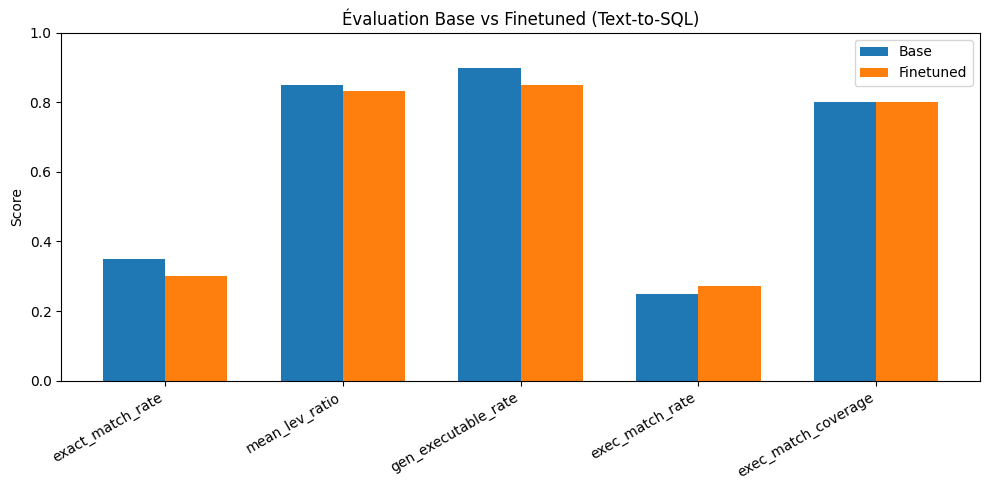

Saved plot to eval_summary_base_vs_finetuned.png


In [41]:
# @title Bar chart: Base vs Finetuned

metrics = list(summary_base.keys())
base_vals = [summary_base[m] for m in metrics]
ft_vals   = [summary_ft[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, base_vals, width, label="Base")
plt.bar(x + width/2, ft_vals, width, label="Finetuned")

plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Évaluation Base vs Finetuned (Text-to-SQL)")
plt.legend()
plt.tight_layout()
plt.savefig("eval_summary_base_vs_finetuned.png")
plt.show()

print("Saved plot to eval_summary_base_vs_finetuned.png")
